# 🍽️ Restaurant Tips Data Analysis
**Author:** Pius Victor  
**Date:** 01-03-2026  

In this project, I analyze restaurant tipping behavior using a real-world dataset. I'll explore how factors like the total bill, day of the week, and group size influence tip amounts.

## 1. Import Libraries
These are the tools we'll use throughout the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries imported successfully! ✅')

Libraries imported successfully! ✅


## 2. Load the Dataset
We're using the **Tips** dataset, which is built directly into the seaborn library — no download needed!

In [40]:
# Load the dataset
df = sns.load_dataset('tips')

# Preview the first 5 rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 3. Explore the Data
Let's understand what we're working with before diving into analysis.

In [3]:
# How many rows and columns?
print('Shape of dataset:', df.shape)
print()

# Column names and data types
print('Column info:')
print(df.info())

Shape of dataset: (244, 7)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


In [4]:
# Basic statistics
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


## 4. Data Cleaning
We'll add a new column to make our analysis easier — **tip percentage**.

In [6]:
# Create a new column: tip as a percentage of total bill
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

print('New column added: tip_pct')
df[['total_bill', 'tip', 'tip_pct']].head()

New column added: tip_pct


,total_bill,tip,tip_pct
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


## 5. Analysis & Visualization
Now for the fun part — let's answer some interesting questions!

### 5.1 How are tips distributed?

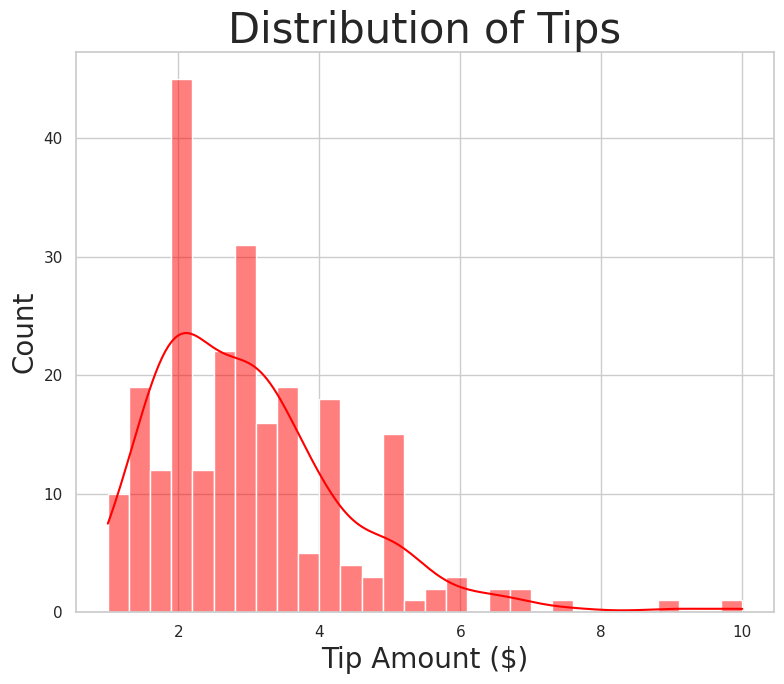

Average tip: $3.00
Median tip: $2.90
Most occurred tip: $2.00
Most common day: Sat
Most common group size: 2


In [30]:
plt.figure(figsize=(8, 7))
sns.histplot(df['tip'], bins=30, color='red', kde=True)
plt.title('Distribution of Tips', fontsize=30)
plt.xlabel('Tip Amount ($)', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.tight_layout()
plt.savefig('tip_distribution.png', dpi=150)
plt.show()

print(f'Average tip: ${df["tip"].mean():.2f}')
print(f'Median tip: ${df["tip"].median():.2f}')
print(f'Most occurred tip: ${df["tip"].mode()[0]:.2f}')
print(f'Most common day: {df["day"].mode()[0]}')
print(f'Most common group size: {df["size"].mode()[0]}')

### 5.2 Does a higher bill lead to a higher tip?

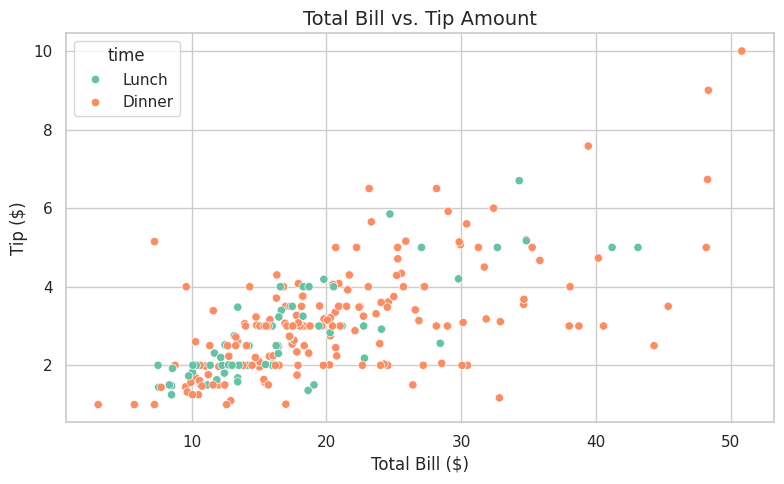

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', palette='Set2')
plt.title('Total Bill vs. Tip Amount', fontsize=14)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.savefig('bill_vs_tip.png', dpi=150)
plt.show()

### 5.3 Which day gets the highest tips?

/tmp/ipython-input-251/3840263145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='tip', order=day_order, palette='pastel')


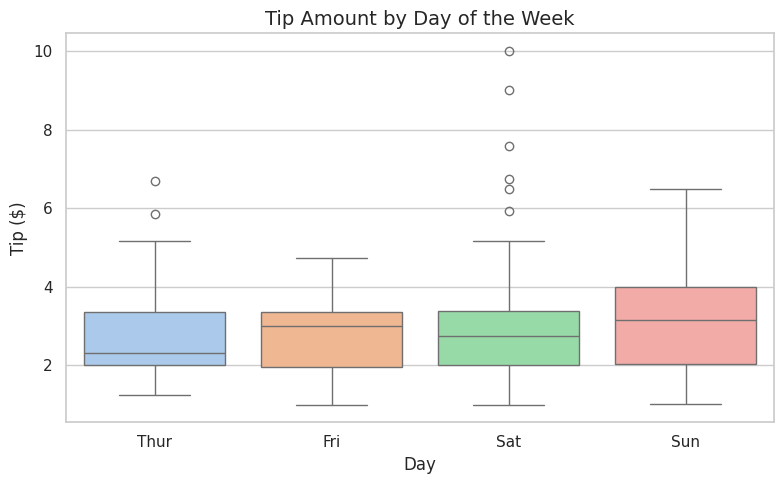

Average tip per day:
day
Thur    2.77
Fri     2.73
Sat     2.99
Sun     3.26
Name: tip, dtype: float64


/tmp/ipython-input-251/3840263145.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('day')['tip'].mean().round(2))


In [39]:
plt.figure(figsize=(8, 5))
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
sns.boxplot(data=df, x='day', y='tip', order=day_order, palette='pastel')
plt.title('Tip Amount by Day of the Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.savefig('tips_by_day.png', dpi=150)
plt.show()

# Average tip per day
print('Average tip per day:')
print(df.groupby('day')['tip'].mean().round(2))

### 5.4 Does group size affect tip percentage?

/tmp/ipython-input-251/4088181000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='size', y='tip_pct', palette='pastel')


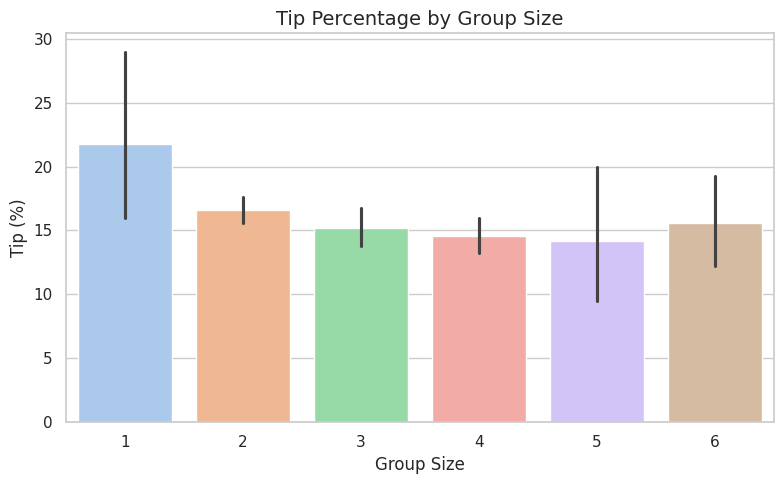

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='size', y='tip_pct', palette='pastel')
plt.title('Tip Percentage by Group Size', fontsize=14)
plt.xlabel('Group Size')
plt.ylabel('Tip (%)')
plt.tight_layout()
plt.savefig('tips_by_size.png', dpi=150)
plt.show()

## 6. Summary & Conclusion

Here's what we found from our analysis:

- **Average tip** is around **\$3.00** and most tips fall between **\$2 and $4**.

- **There is a positive relationship** between total bill and tip amount — the more someone spends, the more they tip.

- **Sunday and Saturday** tend to have slightly higher tip amounts, likely because of larger weekend crowds.

- **Smaller groups (1–2 people)** tend to tip a higher percentage compared to larger tables.

These insights could be useful for restaurant owners to understand customer behavior and staff scheduling!